# 02 — WoE binning and Information Value

**Goal:** bin every candidate feature, convert bins to Weight of Evidence, and rank
features by Information Value (IV).

$$\text{WoE}_i = \ln\frac{\%\text{good}_i}{\%\text{bad}_i} \qquad
\text{IV} = \sum_i (\%\text{good}_i - \%\text{bad}_i)\,\text{WoE}_i$$

Positive WoE = safer than average. Bins are fitted on **train only**.

In [1]:
import os, sys, pickle
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pdmodel import config as C
pd.set_option("display.float_format", "{:.4f}".format)
PROC = ROOT / "data" / "processed"
from pdmodel import plots
from pdmodel.woe import WoEBinner

In [2]:
S = pd.read_pickle(PROC / "samples.pkl")
train = S["train"]

## 1. Fit the binner
For each numeric feature (see `src/pdmodel/woe.py`):
1. start from 10 quantile bins,
2. merge any bin with < 5% of the sample (small bins = noisy WoE),
3. merge adjacent bins until the bad rate is **monotonic** (always rising or always falling).

Step 3 is a business choice: it guarantees, for example, that a higher FICO can never
get *fewer* points, which credit officers and regulators expect.

In [3]:
binner = WoEBinner().fit(train, train["default"], C.NUMERIC_FEATURES, C.CATEGORICAL_FEATURES)
iv = binner.iv_table()
iv

,iv,strength,n_bins
fico,0.1417,medium,10
annual_inc,0.0934,weak,11
loan_to_income,0.0414,weak,9
inq_last_6mths,0.0400,weak,5
mort_acc,0.0380,weak,7
purpose,0.0352,weak,10
dti,0.0351,weak,9
revol_util,0.0341,weak,11
home_ownership,0.0311,weak,4
credit_hist_years,0.0206,weak,8


IV rule of thumb: < 0.02 useless · 0.02–0.1 weak · 0.1–0.3 medium · 0.3–0.5 strong · > 0.5 suspicious (leakage?).

## 2. Look at the bins of the strongest features

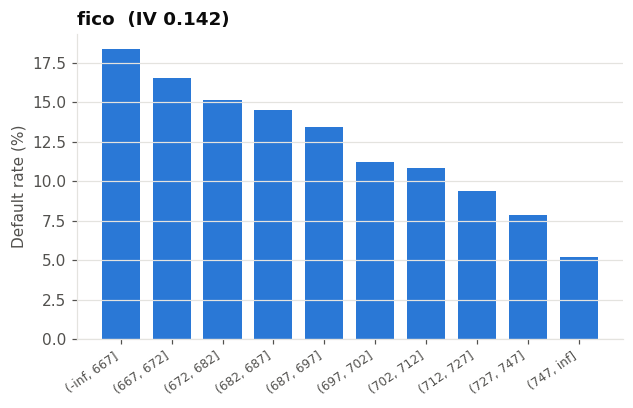

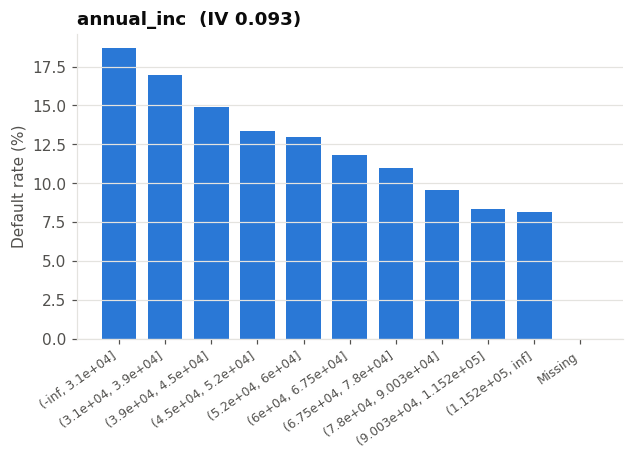

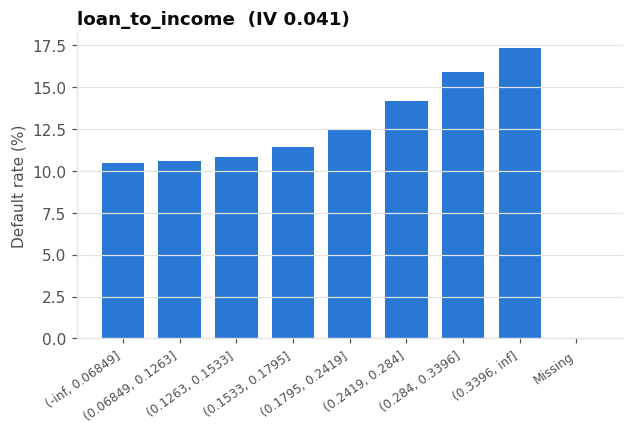

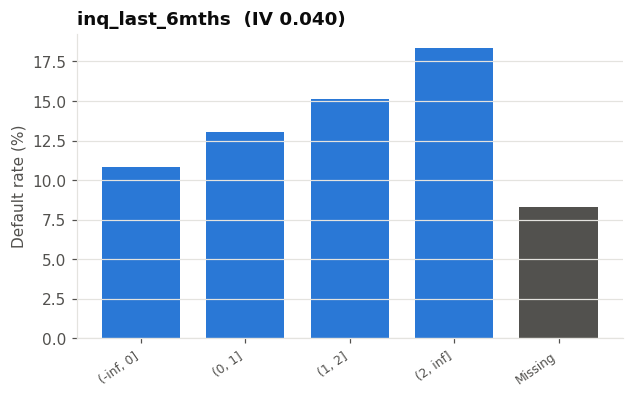

In [4]:
for f in iv.index[:4]:
    plots.woe_plot(binner.bins[f].table); plt.show()

In [5]:
binner.bins[iv.index[0]].table

,feature,bin,n,pct_of_sample,bads,bad_rate,woe,iv_contrib
0,fico,"(-inf, 667]",16419.0000,0.1337,3020.0000,0.1839,-0.4442,0.0310
1,fico,"(667, 672]",9180.0000,0.0748,1519.0000,0.1655,-0.3162,0.0084
2,fico,"(672, 682]",18243.0000,0.1486,2758.0000,0.1512,-0.2088,0.0070
3,fico,"(682, 687]",8704.0000,0.0709,1261.0000,0.1449,-0.1590,0.0019
4,fico,"(687, 697]",16624.0000,0.1354,2232.0000,0.1343,-0.0704,0.0007
5,fico,"(697, 702]",7266.0000,0.0592,815.0000,0.1122,0.1342,0.0010
6,fico,"(702, 712]",12189.0000,0.0993,1322.0000,0.1085,0.1722,0.0028
7,fico,"(712, 727]",12963.0000,0.1056,1219.0000,0.0940,0.3309,0.0102
8,fico,"(727, 747]",9735.0000,0.0793,767.0000,0.0788,0.5243,0.0179
9,fico,"(747, inf]",11475.0000,0.0934,597.0000,0.0520,0.9678,0.0608


## 3. Categorical features
Rare categories (< 1%) are pooled into `OTHER` so their WoE isn't driven by a handful of loans.

In [6]:
binner.bins["purpose"].table

,feature,bin,n,pct_of_sample,bads,bad_rate,woe,iv_contrib
0,purpose,small_business,2466.0000,0.0201,554.0000,0.2247,-0.6959,0.0125
1,purpose,other,7452.0000,0.0607,1207.0000,0.1620,-0.2907,0.0057
2,purpose,OTHER,3052.0000,0.0249,480.0000,0.1573,-0.2562,0.0018
3,purpose,medical,1338.0000,0.0109,209.0000,0.1562,-0.2492,0.0007
4,purpose,debt_consolidation,67125.0000,0.5466,8708.0000,0.1297,-0.0307,0.0005
5,purpose,wedding,1373.0000,0.0112,160.0000,0.1165,0.0889,0.0001
6,purpose,home_improvement,7002.0000,0.0570,784.0000,0.1120,0.1362,0.0010
7,purpose,credit_card,27857.0000,0.2269,2906.0000,0.1043,0.2160,0.0098
8,purpose,car,1860.0000,0.0151,185.0000,0.0995,0.2668,0.0010
9,purpose,major_purchase,3273.0000,0.0267,317.0000,0.0969,0.2973,0.0021


In [7]:
pd.to_pickle(binner, PROC / "binner.pkl")

## ✍️ Try it
- Re-fit with `WoEBinner(monotonic=False)`. Which features change most? Is the extra IV worth the loss of explainability?
- Change `MIN_BIN_FRAC` to 0.02. What happens to IV on train vs. stability later?

## ✍️ Interview prep
1. Why does WoE make logistic regression a good fit for scorecards?
2. Why fit bins on train only?
3. A feature has IV = 0.9. What do you do?